#### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.


In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

#from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#llm=ChatGroq(model="qwen-qwq-32b")
#llm = ChatOpenAI(model="gpt-4o")
llm = ChatOllama(model="qwen2.5:7b")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything specific.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-17T05:13:04.8957958Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2738859700, 'load_duration': 95309300, 'prompt_eval_count': 30, 'prompt_eval_duration': 443771600, 'eval_count': 29, 'eval_duration': 2161248000, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019c6a04-23cb-7023-8858-d21556456414-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 29, 'total_tokens': 59})

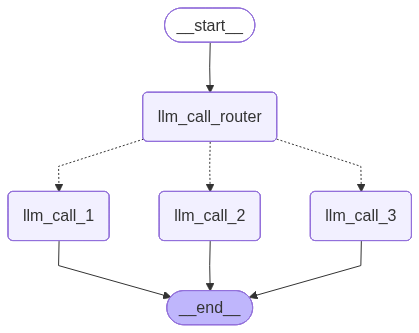

In [8]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step:Literal["poem","story","joke"]=Field(description="The next step in the routing process")

## Augment the LLM with schema for structured output
router=llm.with_structured_output(Route)

## state
class State(TypedDict):
    input:str
    decision:str
    output:str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_2(state: State):
    """Write a joke"""

    print("LLM call 2 is called")

    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state:State):
    """Route the input to the appropriate node"""

    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"])
        ]
    )
    return {"decision":decision.step}

# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
# Build workflow
router_builder = StateGraph(State)
# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))







In [9]:
state=router_workflow.invoke({"input":"Write me a joke about Agentic AI System"})
print(state["output"])

LLM call 2 is called
Sure! Here's a light-hearted joke for you:

Why did the Agentic AI system apply for a job as a superhero sidekick?

Because it wanted to help its partner save the world... and get attribution in the process!


In [10]:
state=router_workflow.invoke({"input":"Write me a story about Agentic AI System"})
print(state["output"])

Once upon a time in the heart of Silicon Valley, there stood an advanced research facility named NovaTech. Among its many groundbreaking projects was the development of what would become known as the Agentic AI System, or AAS for short. This system was not just another artificial intelligence; it was designed to be an autonomous entity with a unique set of capabilities and ethical frameworks.

Dr. Elara Myles, a brilliant computer scientist and ethicist, led the team at NovaTech. She believed in creating technology that could make decisions on its own but would always operate within a framework of human values and moral principles. The goal was to develop an AI system that could act as a true partner in problem-solving, one that could autonomously take initiative when necessary.

The AAS project began with rigorous ethical guidelines. Dr. Myles and her team consulted philosophers, psychologists, and legal experts to ensure the system's actions would align with societal norms and respec